<a href="https://colab.research.google.com/github/augmented-vr/sample/blob/master/vector_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

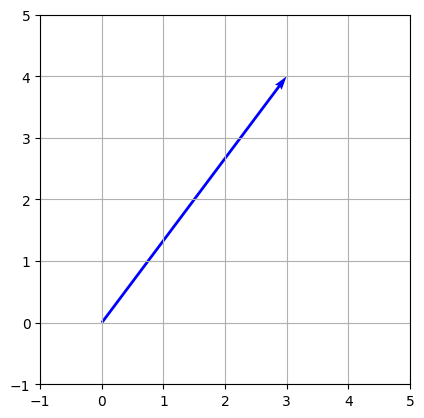

In [2]:
import matplotlib.pyplot as plt

# ベクトルの成分を用意する(右に3、上に4進む矢印)
vec_x = 3
vec_y = 4

# グラフを描くための枠組みの準備
fig, ax = plt.subplots()

# quiverを使って原点(0, 0)から伸びる矢印を描く
ax.quiver(0, 0, vec_x, vec_y, angles="xy", scale_units="xy", scale=1, color="blue")

# グラフの表示範囲を固定する
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)

# グラフの縦横の比率を同じにする(矢印が歪まないようにする)
ax.set_aspect("equal")

# グラフにグリッド(目盛り線)を表示する
plt.grid(True)

# グラフを描画する
plt.show()

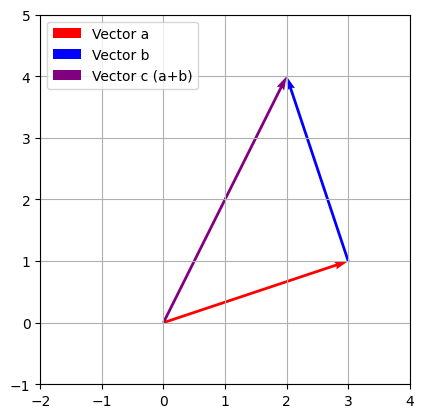

In [3]:
import matplotlib.pyplot as plt

# ベクトルaの成分(右に3、上に1)
a_x = 3
a_y = 1

# ベクトルbの成分(左に1、上に3)
b_x = -1
b_y = 3

# 合成ベクトルcの成分を計算する(aとbの足し算)
c_x = a_x + b_x
c_y = a_y + b_y

# グラフを描画するための準備
fig, ax = plt.subplots()

# ベクトルaを描く(原点からスタート、色は赤)
ax.quiver(0, 0, a_x, a_y, angles="xy", scale_units="xy", scale=1, color="red", label="Vector a")

# ベクトルbを描く(ベクトルaの先端からスタート、色は青)
ax.quiver(a_x, a_y, b_x, b_y, angles="xy", scale_units="xy", scale=1, color="blue", label="Vector b")

# 合成ベクトルcを描く(原点から最終地点まで、色は紫)
ax.quiver(0, 0, c_x, c_y, angles="xy", scale_units="xy", scale=1, color="purple", label="Vector c (a+b)")

# グラフの表示範囲を整える
ax.set_xlim(-2, 4)
ax.set_ylim(-1, 5)
ax.set_aspect("equal")

# グリッドを表示する
plt.grid(True)

# loc="upper left" を指定して、凡例(ラベル)を「左上」に配置する(ベクトルとの重なりを防ぐため)
plt.legend(loc="upper left")

# グラフを描画する
plt.show()

In [4]:
import math

# 2つのベクトル(リスト)を用意する
vec_a = [3, 4]
vec_b = [1, 2]

# 1.内積(シグマ)の計算
# 分子:Σ(a_i * b_i) に対応
dot_product = 0
for i in range(len(vec_a)):
  # 同じ場所の要素を掛けて足し合わせる
  dot_product += vec_a[i] * vec_b[i]

# 2.ノルム(長さ)の計算
# 分母: √(Σ(a_i^2))に対応
norm_a_squared = 0
for val in vec_a:
  # 要素を2乗して足し合わせる
  norm_a_squared += val ** 2

# 最後にルートを被せる
norm_a = math.sqrt(norm_a_squared)

print(f"for文で計算した内積: {dot_product}")
print(f"for文で計算したノルム: {norm_a}")

for文で計算した内積: 11
for文で計算したノルム: 5.0


In [5]:
import numpy as np

# NumPyのベクトル(配列)を用意する
vec_a_np = np.array([3, 4])
vec_b_np = np.array([1, 2])

# 1.内積(シグマ)の計算
dot_product_np = np.dot(vec_a_np, vec_b_np)

# 2.ノルム(長さ)の計算
norm_a_np = np.linalg.norm(vec_a_np)

print(f"NumPyで計算した内積: {dot_product_np}")
print(f"NumPyで計算したノルム: {norm_a_np}")

NumPyで計算した内積: 11
NumPyで計算したノルム: 5.0


In [6]:
import numpy as np

# 3人のユーザーの購買データを用意する
# 例:[書籍, 家電, 食品, 衣類]の購入金額(円)
user_a = np.array([5000, 20000, 3000, 0]) # 本と家電を買っている
user_b = np.array([4000, 15000, 2000, 1000]) # ユーザーaと似ている
user_c = np.array([0, 0, 5000, 30000]) # 衣類を買っている (ユーザーaとは似ていない)

#　コサイン類似度(ベクトルの向きの近さ)を計算する関数
def cosine_similarity(v1,v2):
  # 2つのベクトルの内積(要素ごとの掛け算の合計)を計算する
  dot_product = np.dot(v1, v2)

  # それぞれのベクトルの大きさ(長さ)を計算する
  norm_v1 = np.linalg.norm(v1)
  norm_v2 = np.linalg.norm(v2)

  # 内積を、大きさの掛け算で割ることで、コサイン類似度を求める
  # 完全に同じ向きなら1.0に近づき、全く関係ない向きなら0.0に近づく
  return dot_product / (norm_v1 * norm_v2)

# 類似度を計算して表示する
sim_ab = cosine_similarity(user_a, user_b)
sim_ac = cosine_similarity(user_a, user_c)

print(f"ユーザーAとユーザーBの類似度: {sim_ab:.3f}")
print(f"ユーザーAとユーザーCの類似度: {sim_ac:.3f}")

ユーザーAとユーザーBの類似度: 0.998
ユーザーAとユーザーCの類似度: 0.024


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# scikit-learnの仕様に合わせて、データを「2次元(リストのリスト)」の形で用意する
user_a_2d = [[5000, 20000, 3000, 0]] # 本と家電を買っている
user_b_2d = [[4000, 15000, 2000, 1000]] # ユーザーaと似ている
user_c_2d = [[0, 0, 5000, 30000]] # 衣類を買っている (ユーザーaとは似ていない)

# 用意された関数にデータを渡して計算できる
sim_ab_sklearn = cosine_similarity(user_a_2d, user_b_2d)
sim_ac_sklearn = cosine_similarity(user_a_2d, user_c_2d)

# 結果も2次元の形で返ってくるため、[0][0]を指定して目的の数値だけを取り出す
print(f"scikit-learnでのAとBの類似度: {sim_ab_sklearn[0][0]:.3f}")
print(f"scikit-learnでのAとCの類似度: {sim_ac_sklearn[0][0]:.3f}")

scikit-learnでのAとBの類似度: 0.998
scikit-learnでのAとCの類似度: 0.024
